In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from ates import evaluate
from ates.models import autoatesv2
from ates.validate import Validator

# Validate AutoATES v2

Validate model against what Avalanche Canada already publish online.


In [2]:
import autoates_v2

bow_summit_data = (Path(autoates_v2.__file__).parent / "test-data" / "Bow Summit").resolve()

## Bow Summit

No Avalanche Canada ground truth exists for Bow Summit. Instead we validate
reproducibility: run the classifier fresh and compare against the reference
output (`ates_gen.tif`) bundled with the autoatesv2 package.

In [3]:
import rasterio
import numpy as np

from ates.models import autoatesv2

# Run classifier fresh
predicted = autoatesv2.run(
    dem=bow_summit_data / "dem.tif",
    transform=None,  # file path — transform read from file
    canopy=bow_summit_data / "forest.tif",
    cell_count=bow_summit_data / "Overhead.tif",
    fp=bow_summit_data / "FP_int16.tif",
    sz=bow_summit_data / "pra_binary.tif",
)

# Load reference output
with rasterio.open(bow_summit_data / "outputs" / "ates_gen.tif") as src:
    reference = src.read(1)

print(f"Predicted shape: {predicted.shape}, Reference shape: {reference.shape}")
print(f"Predicted classes: {np.unique(predicted)}")
print(f"Reference classes: {np.unique(reference)}")

Predicted shape: (242, 218), Reference shape: (242, 218)
Predicted classes: [-9999     1     2     3     4]
Reference classes: [-9999     1     2     3     4]


/home/jack/repos/avalanche/ice-autoATES/.venv/lib/python3.13/site-packages/osgeo/gdal.py:314: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [4]:
evaluate.report(predicted, reference)

              precision    recall  f1-score   support

      Simple       1.00      1.00      1.00     17334
 Challenging       1.00      1.00      1.00      3307
     Complex       1.00      1.00      1.00      8347

   micro avg       1.00      1.00      1.00     28988
   macro avg       1.00      1.00      1.00     28988
weighted avg       1.00      1.00      1.00     28988



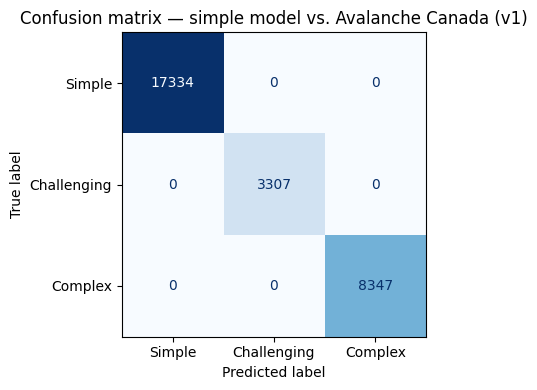

In [5]:
evaluate.plot_confusion_matrix(predicted, reference)

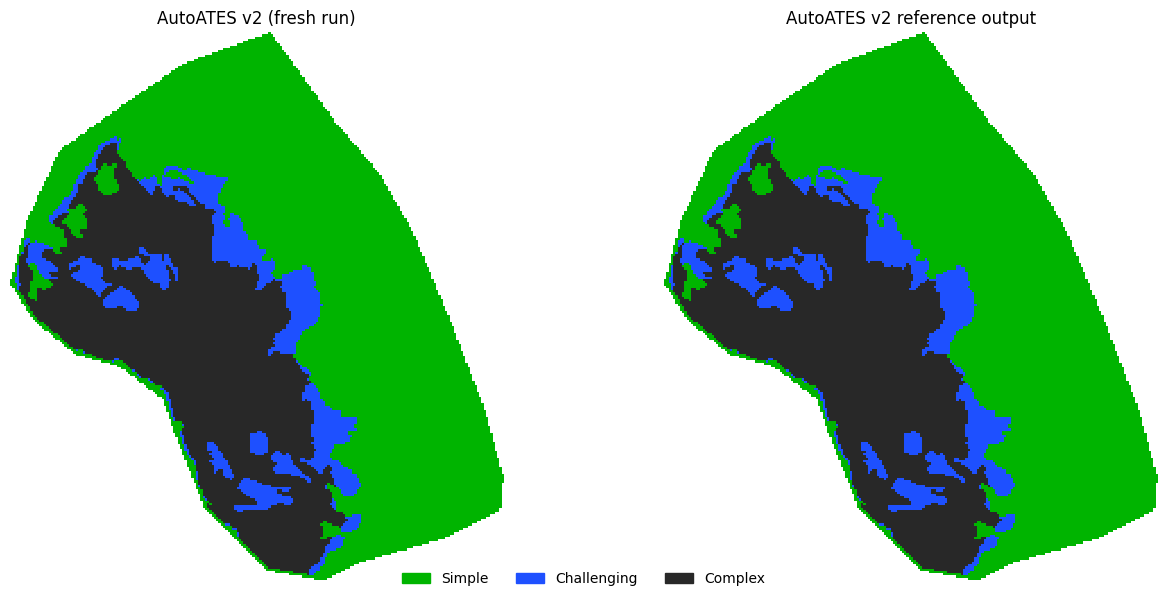

In [6]:
evaluate.plot_side_by_side(
    predicted, reference,
    predicted_title="AutoATES v2 (fresh run)",
    truth_title="AutoATES v2 reference output",
)